In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

import missingno as msno

from sklearn.model_selection import train_test_split

Metadata : 

        Context
        "Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs."

        Content
        Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

        The data set includes information about:

        Customers who left within the last month – the column is called Churn
        Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
        Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
        Demographic info about customers – gender, age range, and if they have partners and dependents

In [2]:
df = pd.read_csv('telco-churn-dataset.csv')

In [3]:
df.shape # A lot of features

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
# So in simple words we have to train our model in such a way that give a unknown row next we will be able to predict whether the customer churns or not.

In [7]:
# There are various columns that will be heping us do this task where the output is the Churn column 

In [8]:
# Let's look at whether the column is balanced or not 
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
# As expected is not balanced so we need to keep that in mind while model building 

In [10]:
# Let's Analyse this dataset deeply

In [11]:
df.columns # The name of all the columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
# There seem to be no Null values but who knows ? ; There maybe some anamolies hiding beneath.
# Many of the columns have dtype = object ; a strategy need to be devised to convert them to numbers
# Also I need to check before hand that whether there are many columns that are correlated to each other
# Cause if so we need to reduce features.

In [14]:
# I want to peek at the number of unique values beforehand to know the diversity of these categorical columns
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [15]:
# Good : From this one thing is clear that the Numeric columns are the only columns with distributed values across dataset and 
# there is no such categorical column with lot of classes
# Also oddly the TotalCharges column is in object --- > Need more investigation

In [16]:
# Also I think the customerID will not provide any info to the model so I am dropping it before hand
df = df.drop(columns=['customerID'])

In [17]:
df.head() # So we now we will deal with one column less

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# Now let's do univariate Analysis on Numeric Values

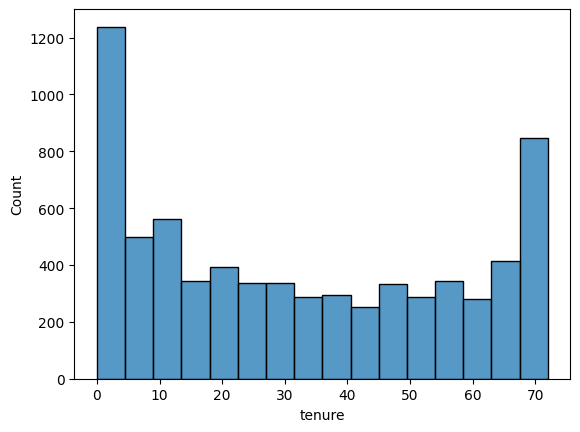

In [19]:
sns.histplot(
                data = df,
                x = 'tenure'
)
plt.show()
# A clear insight how the tenure is not distributed unformly and the highest counts are towards the boundary values

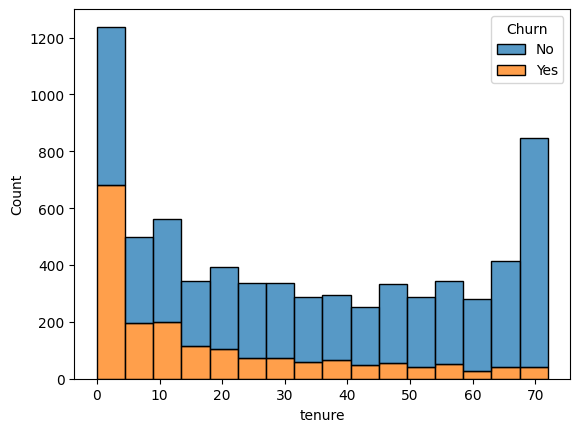

In [20]:
sns.histplot(
                data = df,
                x = 'tenure',
                hue = 'Churn',
                multiple='stack',
                # kde = True,
)
plt.show()
# Also when I set the hue = Churn look what I found

In [21]:
# Many people who have churned had tenure = 0
# Also if we look carefully there is a decreasing trend towards increasing tenure clearly stating a relationship

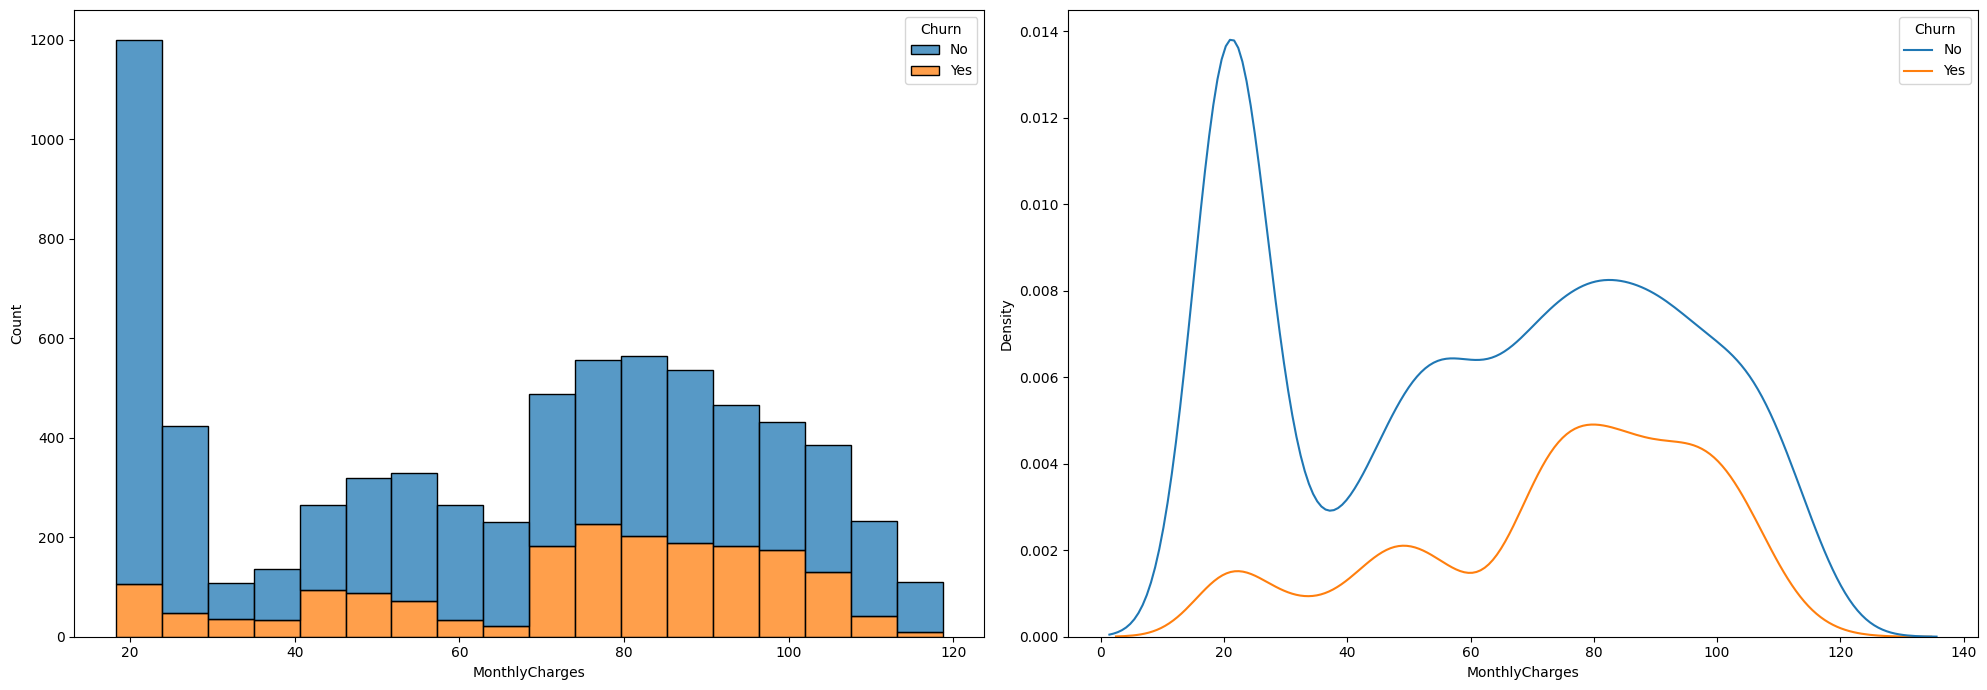

In [22]:
# Now moving on to the Monthly charges and total charges
# I think we should compare this plots side by side

plt.figure(figsize=(20,7))

plt.subplot(121)
sns.histplot(
                df,
                x='MonthlyCharges',
                hue='Churn',
                multiple='stack'
            )

plt.subplot(122)
sns.kdeplot(
                df,
                x ='MonthlyCharges',
                hue = 'Churn'
            )

plt.tight_layout()
plt.show()



In [23]:
# The MonthlyCharges column is heavily right tailed and we may need some measurement to deal with this
# Another observation caught in kdeplot is after a certain point there seemed to be a plateu seen between charges 60 to 120
# There might me some info for our model here as well

In [24]:
[df['TotalCharges'].min(),df['TotalCharges'].max()]
# We can clearly see that this column is dirty anf may rows which do not have a real numeric value

[' ', '999.9']

In [25]:
df[df['TotalCharges'] == ' '] # So basically these many rows are having TotalCharges as Empty
# Also dont know whether this is related or not but all of these people do not churn and have dependents

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [26]:
# I did a quick check to look what happened when we forcefully tried to convert the strings into numeric
# and strangely 11 rows were fale because they were na which we just above earlier
pd.to_numeric(df['TotalCharges'], errors='coerce').isna().value_counts()
# We can either drop these rows or we can either assign a value for this 

TotalCharges
False    7032
True       11
Name: count, dtype: int64

In [27]:
# Since the no of rows are too less to have any significance I will just drop these rows for now and then convert the column to numeric
df = df[df['TotalCharges'] != ' ']

In [28]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='raise')

In [29]:
df['TotalCharges'].dtype

dtype('float64')

In [30]:
# Now the thing is we still have many categorical columns to analyze 

In [31]:
df.select_dtypes('object').columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [32]:
# First let's focus on columns with binary classes and then also map them to binary value
(df.nunique() == 2)

gender               True
SeniorCitizen        True
Partner              True
Dependents           True
tenure              False
PhoneService         True
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling     True
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn                True
dtype: bool

In [33]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [34]:
# A quick skim on the values associated for each binary_class_columns
binary_columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService','Churn','PaperlessBilling']
for column in binary_columns:
    print(f'{df[column].value_counts()} \n ')

gender
Male      3549
Female    3483
Name: count, dtype: int64 
 
SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64 
 
Partner
No     3639
Yes    3393
Name: count, dtype: int64 
 
Dependents
No     4933
Yes    2099
Name: count, dtype: int64 
 
PhoneService
Yes    6352
No      680
Name: count, dtype: int64 
 
Churn
No     5163
Yes    1869
Name: count, dtype: int64 
 
PaperlessBilling
Yes    4168
No     2864
Name: count, dtype: int64 
 


In [35]:
# There is a weight imbalance in columns :
'''  
SeniorCitizen , Dependents , PhoneService , Churn , PaperlessBilling
'''

'  \nSeniorCitizen , Dependents , PhoneService , Churn , PaperlessBilling\n'

In [36]:
# Also only the gender column has a seperate map function needed
# Rest all the columns need a same map function of Yes and No
# Also the SeniorCitizens column can be just converted to numeric like we did with Total Charges 

In [37]:
df['gender'] = df['gender'].map({'Male':1,"Female":0})

In [38]:
df['SeniorCitizen'] = pd.to_numeric(df['SeniorCitizen'],errors='raise')

In [39]:
binary_columns.remove('SeniorCitizen')
binary_columns.remove('gender')

In [40]:
df[binary_columns] = df[binary_columns].map( lambda x : 1 if x == 'Yes' else 0)

In [41]:
df[binary_columns].head()

,Partner,Dependents,PhoneService,Churn,PaperlessBilling
0,1,0,0,0,1
1,0,0,1,0,0
2,0,0,1,1,1
3,0,0,0,0,0
4,0,0,1,1,1


In [73]:
df.select_dtypes('object').nunique()

InternetService    3
Contract           3
PaymentMethod      4
dtype: int64

In [75]:
object_cols = df.select_dtypes('object').nunique().index

In [44]:
# Now we are left with these many categorical columns
# Also let's just quickly examine the unique values of each column to get a grasp of the balance of classes in each

In [76]:
for x in object_cols:
    print(f'{df[x].value_counts()} \n')

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64 

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64 

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64 



In [46]:
# We can see clearly that exactly 1520 people / rows had no internet service which is refelcted well in the value_counts

In [ ]:
# There are two strategies : 
''' 
Either we can combine the No and No internet Service column into a single class encode together

We keep the originallity ad we make a new column No internet Service which will inherit from the internet service
    This way we can convert all the other column's no into no and make the column a binary class
'''

In [47]:
# I am going with the second approach because I think that is the best at the point

In [ ]:
df['NoInternetService'] = (df['InternetService'] == 'No').astype('int')

# Doing this will surely remove the correlation between these columns but we will still have the No value for InternetService column
# Maybe I guess there was no need to even make these column and we could have just made the other cols NoInternetService as No 
# This way we could have made sure that the columns each become independent and the InternetService column will then have a large weight

In [57]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,NoInternetService
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,0
1,1,0,0,0,34,1,No,DSL,Yes,No,...,No,No,No,One year,0,Mailed check,56.95,1889.50,0,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0


In [58]:
# This reduced our load a lot because now we can map many columns to a single binary feature

In [68]:
cols_to_binary = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
df[cols_to_binary] = df[cols_to_binary].map( lambda x : 1 if x == 'Yes' else 0)

In [ ]:
# We also will be doing the same to MultipleLines as it also has a column of PhoneService

In [71]:
df['MultipleLines'] = df['MultipleLines'].map(lambda x : 1 if x == 'Yes' else 0)

In [72]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,NoInternetService
0,0,0,1,0,1,0,0,DSL,0,1,...,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0,0
1,1,0,0,0,34,1,0,DSL,1,0,...,0,0,0,One year,0,Mailed check,56.95,1889.50,0,0
2,1,0,0,0,2,1,0,DSL,1,1,...,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,0
3,1,0,0,0,45,0,0,DSL,1,0,...,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,...,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,0
